## PRCP-1027: Skin Disorder Classification Project

### Machine Learning Based Analysis and Prediction of Skin Diseases



### Task 1: Exploratory Data Analysis (EDA)

#### Objective:To analyze the dermatology dataset and understand feature distributions, relationships, and class behavior.



In [1]:
#Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load the Dataset

In [2]:
df=pd.read_csv("dataset_35_dermatology (1).csv")
df

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


### Dataset Overview
- Rows: 366 patients
- Columns: 35 features
- Target Variable: Skin disease class



## Basic Inspection

In [3]:
df.head(20)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
5,2,3,2,0,0,0,0,0,0,0,...,0,0,2,0,0,0,1,0,41,2
6,2,1,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,18,5
7,2,2,3,3,3,3,0,2,0,0,...,2,2,3,2,0,0,3,3,57,3
8,2,2,1,0,2,0,0,0,0,0,...,0,0,2,0,0,0,2,0,22,4
9,2,2,1,0,1,0,0,0,0,0,...,0,0,2,0,0,0,2,0,30,4


In [4]:
df.tail(20)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
346,2,2,2,1,0,0,0,0,0,0,...,1,0,2,0,0,0,2,0,40,4
347,2,2,0,1,0,0,2,0,2,0,...,0,0,1,0,2,2,2,0,22,6
348,3,2,2,0,0,0,3,0,1,0,...,0,0,2,0,3,2,2,0,10,6
349,2,2,1,0,0,0,2,0,2,0,...,0,0,3,0,2,2,2,0,7,6
350,1,2,2,2,0,0,0,0,2,2,...,2,0,0,0,0,0,2,0,25,1
351,2,2,2,3,2,0,0,0,2,3,...,3,0,0,0,0,0,2,0,9,1
352,3,2,2,3,2,0,0,0,2,3,...,2,0,0,0,0,0,1,0,55,1
353,1,1,1,2,0,0,0,0,0,0,...,0,0,1,0,0,0,2,0,45,5
354,2,0,1,2,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,56,5
355,2,3,2,3,2,0,0,0,3,2,...,3,0,0,0,0,0,0,0,36,1


In [5]:
df.sample(20)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
175,2,2,2,0,0,0,0,0,3,2,...,2,0,0,0,0,0,3,0,30,1
61,2,1,1,0,0,0,0,0,1,1,...,1,0,0,0,0,0,1,0,40,1
68,3,3,3,2,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,40,5
112,1,1,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,39,5
13,2,3,3,0,0,0,0,0,1,1,...,0,0,0,0,0,0,2,0,10,1
214,3,2,3,2,2,2,0,2,0,0,...,1,2,2,1,0,0,2,3,53,3
30,3,2,1,2,0,0,0,0,1,2,...,2,0,0,0,0,0,1,0,50,1
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
141,2,3,1,2,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,19,1
208,2,3,2,0,0,0,0,0,2,3,...,0,0,0,0,0,0,2,0,33,1


### Data Types and Unique Value Analysis


In [6]:
df.dtypes

erythema                                     int64
scaling                                      int64
definite_borders                             int64
itching                                      int64
koebner_phenomenon                           int64
polygonal_papules                            int64
follicular_papules                           int64
oral_mucosal_involvement                     int64
knee_and_elbow_involvement                   int64
scalp_involvement                            int64
family_history                               int64
melanin_incontinence                         int64
eosinophils_in_the_infiltrate                int64
PNL_infiltrate                               int64
fibrosis_of_the_papillary_dermis             int64
exocytosis                                   int64
acanthosis                                   int64
hyperkeratosis                               int64
parakeratosis                                int64
clubbing_of_the_rete_ridges    

In [7]:
df.nunique()

erythema                                     4
scaling                                      4
definite_borders                             4
itching                                      4
koebner_phenomenon                           4
polygonal_papules                            4
follicular_papules                           4
oral_mucosal_involvement                     4
knee_and_elbow_involvement                   4
scalp_involvement                            4
family_history                               2
melanin_incontinence                         4
eosinophils_in_the_infiltrate                3
PNL_infiltrate                               4
fibrosis_of_the_papillary_dermis             4
exocytosis                                   4
acanthosis                                   4
hyperkeratosis                               4
parakeratosis                                4
clubbing_of_the_rete_ridges                  4
elongation_of_the_rete_ridges                4
thinning_of_t

### Missing Values and Duplicate Records


In [8]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(366, 35)

In [11]:
# Value counts for ALL columns (including Age and class)

print("="*60)
print("VALUE COUNTS FOR ALL 35 FEATURES (including Age & class)".center(60))
print("="*60)
for column in df.columns:   # No skipping anything now
    print(f"\n{column.upper():<40}  -  Total: {len(df)}")
    print("-" * 50)
    counts = df[column].value_counts().sort_index()
    
    # For symptom columns (0-3)
    if column != 'Age' and column != 'class':
        for score in range(4):                # 0 to 3
            print(f"  Score {score}  →  {counts.get(score, 0):>3} patients", end="    ")
        print()                              # new line
    
    # For Age (many unique values) – show top 10 most common
    elif column == 'Age':
        print("Most common ages:")
        print(counts.head(10).to_string())
        print(f"... and {len(counts)-10} more unique ages" if len(counts)>10 else "")
    
    # For class (the 6 diseases)
    else:  # column == 'class'
        disease_names = {
            1: "Psoriasis",
            2: "Seborrhoeic dermatitis", 
            3: "Lichen planus",
            4: "Pityriasis rosea",
            5: "Cronic dermatitis",
            6: "Pityriasis rubra pilaris"
        }
        for val in counts.index:
            name = disease_names.get(val, "Unknown")
            print(f"  Class {val} → {name:<25} → {counts[val]:>3} patients")
    
    print()

  VALUE COUNTS FOR ALL 35 FEATURES (including Age & class)  

ERYTHEMA                                  -  Total: 366
--------------------------------------------------
  Score 0  →    4 patients      Score 1  →   57 patients      Score 2  →  215 patients      Score 3  →   90 patients    


SCALING                                   -  Total: 366
--------------------------------------------------
  Score 0  →    8 patients      Score 1  →  111 patients      Score 2  →  195 patients      Score 3  →   52 patients    


DEFINITE_BORDERS                          -  Total: 366
--------------------------------------------------
  Score 0  →   59 patients      Score 1  →   93 patients      Score 2  →  168 patients      Score 3  →   46 patients    


ITCHING                                   -  Total: 366
--------------------------------------------------
  Score 0  →  118 patients      Score 1  →   72 patients      Score 2  →  100 patients      Score 3  →   76 patients    


KOEBNER_PHENOMENON

### Dataset Description & Key Insights

#### Symptom Scoring
- A total of 33 symptom features are scored on an ordinal scale:
  - **0** → Not present  
  - **1** → Mild  
  - **2** → Moderate  
  - **3** → Severe  

- All symptom columns contain integer values (0, 1, 2, 3).

---

#### Age Feature
- Age represents the patient’s age in years.
- Originally stored as text due to missing values represented by `"?"`.
- Later converted into numeric format for analysis.

---

#### Target Variable (Class)
The class column represents the final diagnosed skin disease:

- **1** → Psoriasis  
- **2** → Seborrheic Dermatitis  
- **3** → Lichen Planus  
- **4** → Pityriasis Rosea  
- **5** → Chronic Dermatitis  
- **6** → Pityriasis Rubra Pilaris  

---

#### Family History Analysis
- 77 patients have a family history of skin disease (value = 1).
- 289 patients have no family history (value = 0).
- Family history is observed more frequently in psoriasis patients.

---

#### Age-Based Insights
- **Youngest patient**: 0 years (newborn)
- **Oldest patient**: 90 years
- **Average age**: Approximately **37 years**
- **Most common age range**: **25–45 years**


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

- Total patients (rows): 366  
- Total columns: 35  

### Feature Composition
- 33 clinical symptom features
- 1 histopathological feature: Family History
- 1 demographic feature: Age
- 1 target variable: Class (Disease Type)


In [13]:
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


### Symptom Severity Observations

- Most symptom features have an average score between 1.0 and 1.8, indicating mild to moderate severity across patients.
- Many symptoms show a value of 0 for a majority of patients, suggesting normal or unaffected skin in those cases.
- The maximum severity score (3) is observed rarely for several features, indicating that extreme symptom presence is uncommon in the dataset.

In [14]:
df.describe(include='O')

,Age
count,366
unique,61
top,40
freq,17


In [15]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [16]:
df.duplicated().sum()

np.int64(0)

### Converting Age Feature into Numeric


In [17]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [18]:
df.dtypes

erythema                                      int64
scaling                                       int64
definite_borders                              int64
itching                                       int64
koebner_phenomenon                            int64
polygonal_papules                             int64
follicular_papules                            int64
oral_mucosal_involvement                      int64
knee_and_elbow_involvement                    int64
scalp_involvement                             int64
family_history                                int64
melanin_incontinence                          int64
eosinophils_in_the_infiltrate                 int64
PNL_infiltrate                                int64
fibrosis_of_the_papillary_dermis              int64
exocytosis                                    int64
acanthosis                                    int64
hyperkeratosis                                int64
parakeratosis                                 int64
clubbing_of_

### Checking Null Values and Duplicate after Conversion

In [19]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

In [20]:
df.duplicated().sum()

np.int64(0)

### Missing Values & Key Observations

#### Missing Values
- Only the Age column contains missing values.
- 8 patients have missing age represented as `"?"`.
- All other 34 columns have no missing values*.

#### Key Observations
- The dataset is mostly clean, with minimal missing data limited to the Age feature.
- All symptom features are properly scored on a 0–3 ordinal scale, as expected.
- The dataset is small (366 records) but of high quality.
- A clear class imbalance exists, particularly for Class 6, which has very few samples.
- The age range is realistic and appropriate for patients with skin diseases.


## EDA (Exploratory Data Analysis)


In [21]:
continuous = ['Age']
ordinal = [
    'erythema','scaling','definite_borders','itching','koebner_phenomenon',
    'polygonal_papules','follicular_papules','oral_mucosal_involvement',
    'knee_and_elbow_involvement','scalp_involvement','family_history',
    'melanin_incontinence','eosinophils_in_the_infiltrate','PNL_infiltrate',
    'fibrosis_of_the_papillary_dermis','exocytosis','acanthosis','hyperkeratosis',
    'parakeratosis','clubbing_of_the_rete_ridges','elongation_of_the_rete_ridges',
    'thinning_of_the_suprapapillary_epidermis','spongiform_pustule',
    'munro_microabcess','focal_hypergranulosis','disappearance_of_the_granular_layer',
    'vacuolisation_and_damage_of_basal_layer','spongiosis',
    'saw-tooth_appearance_of_retes','follicular_horn_plug',
    'perifollicular_parakeratosis','inflammatory_monoluclear_inflitrate',
    'band-like_infiltrate'
]
nominal = ['class']
print("Continuous Features:", continuous)
print("Ordinal Features (Count):", len(ordinal))
print("Nominal Features:", nominal)

Continuous Features: ['Age']
Ordinal Features (Count): 33
Nominal Features: ['class']


#### Univariate Analysis


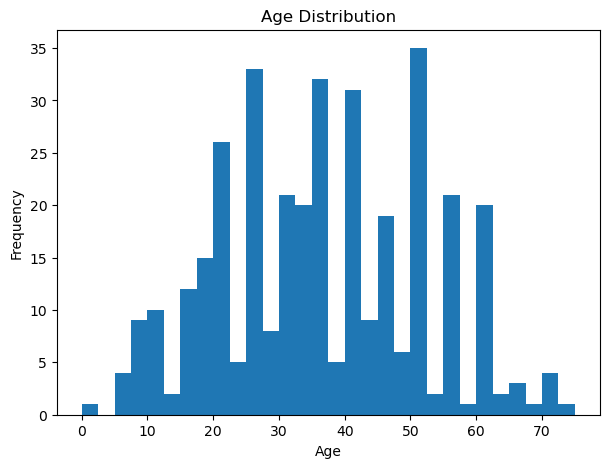

In [22]:
# Distribution of Age

plt.figure(figsize=(7,5))
plt.hist(df['Age'], bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

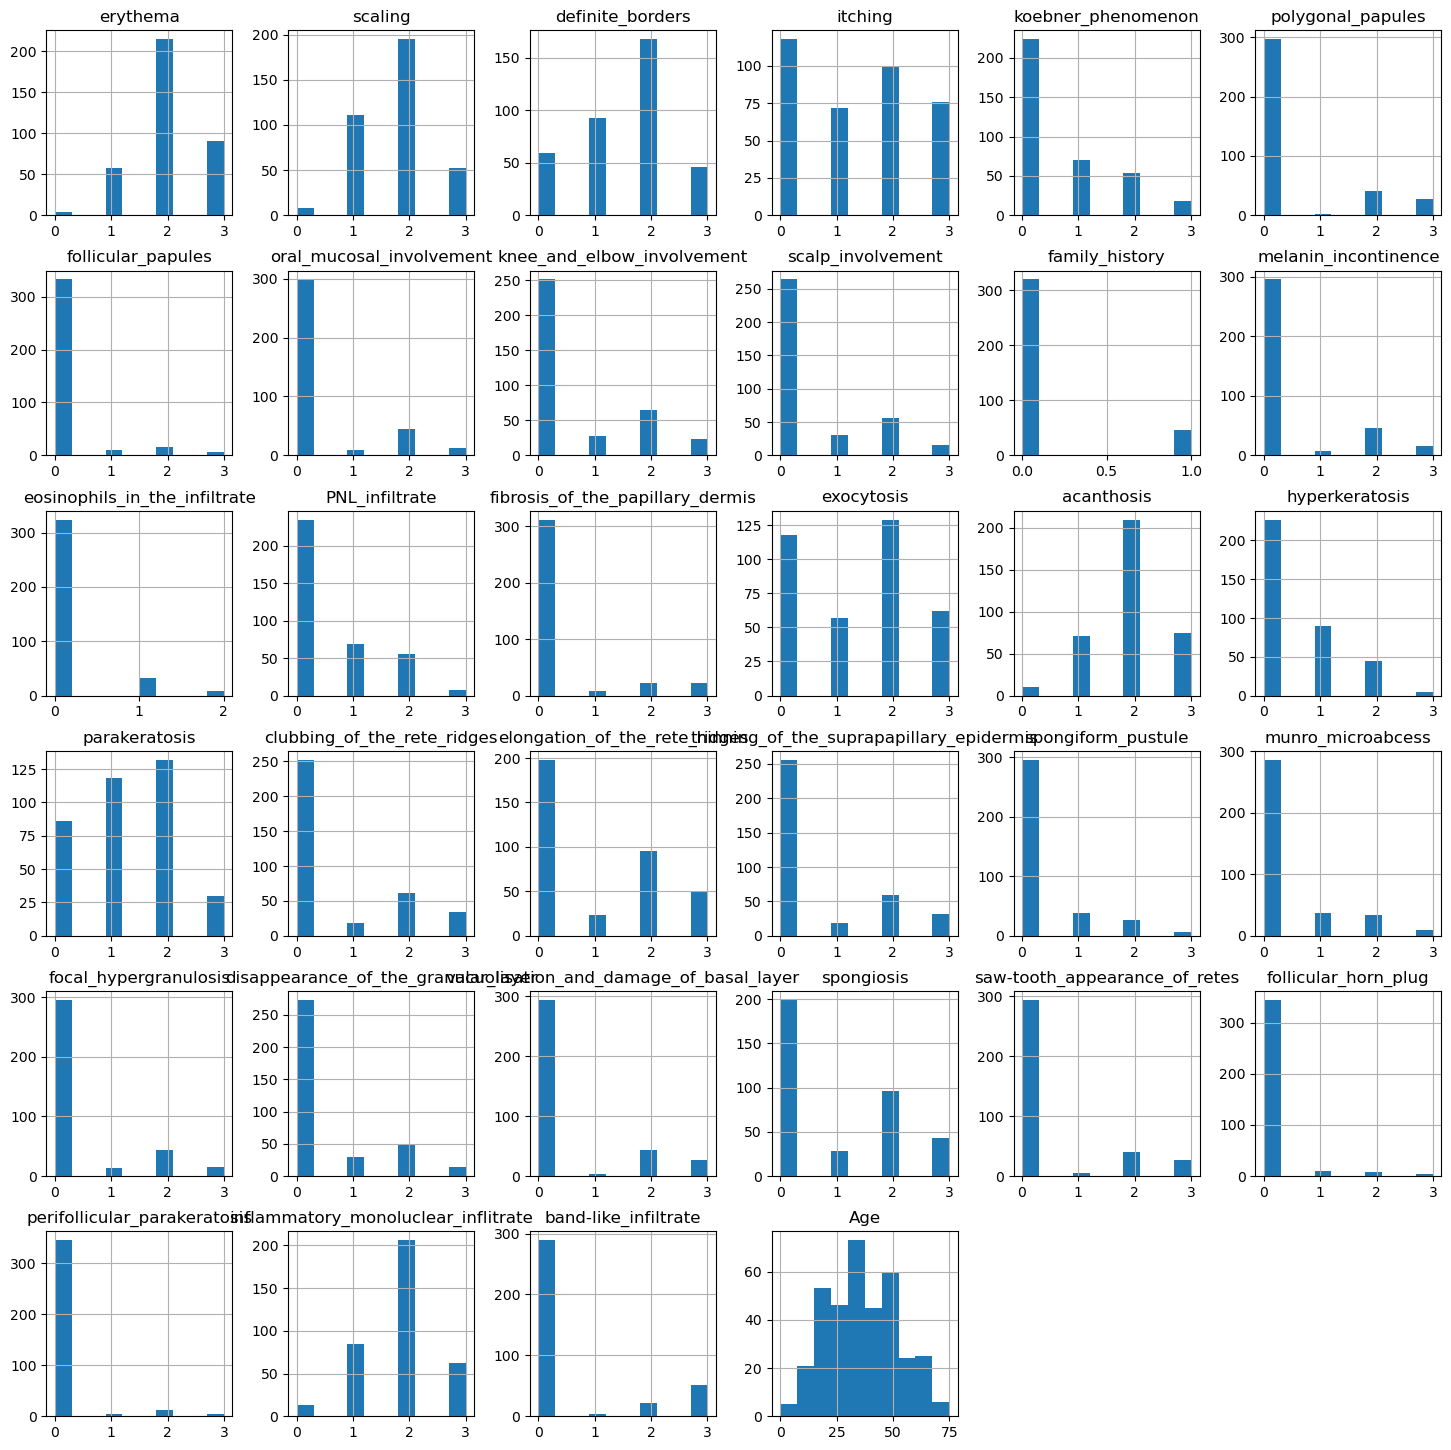

In [23]:
# Histograms of All Features

df.iloc[:, :-1].hist(figsize=(18,18))
plt.show()

#### Bivariate Analysis


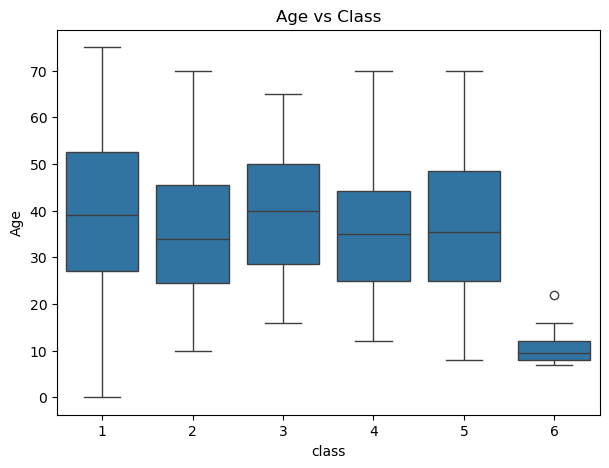

In [24]:
# Age vs Class (Boxplot)

plt.figure(figsize=(7,5))
sns.boxplot(x='class', y='Age', data=df)
plt.title("Age vs Class")
plt.show()

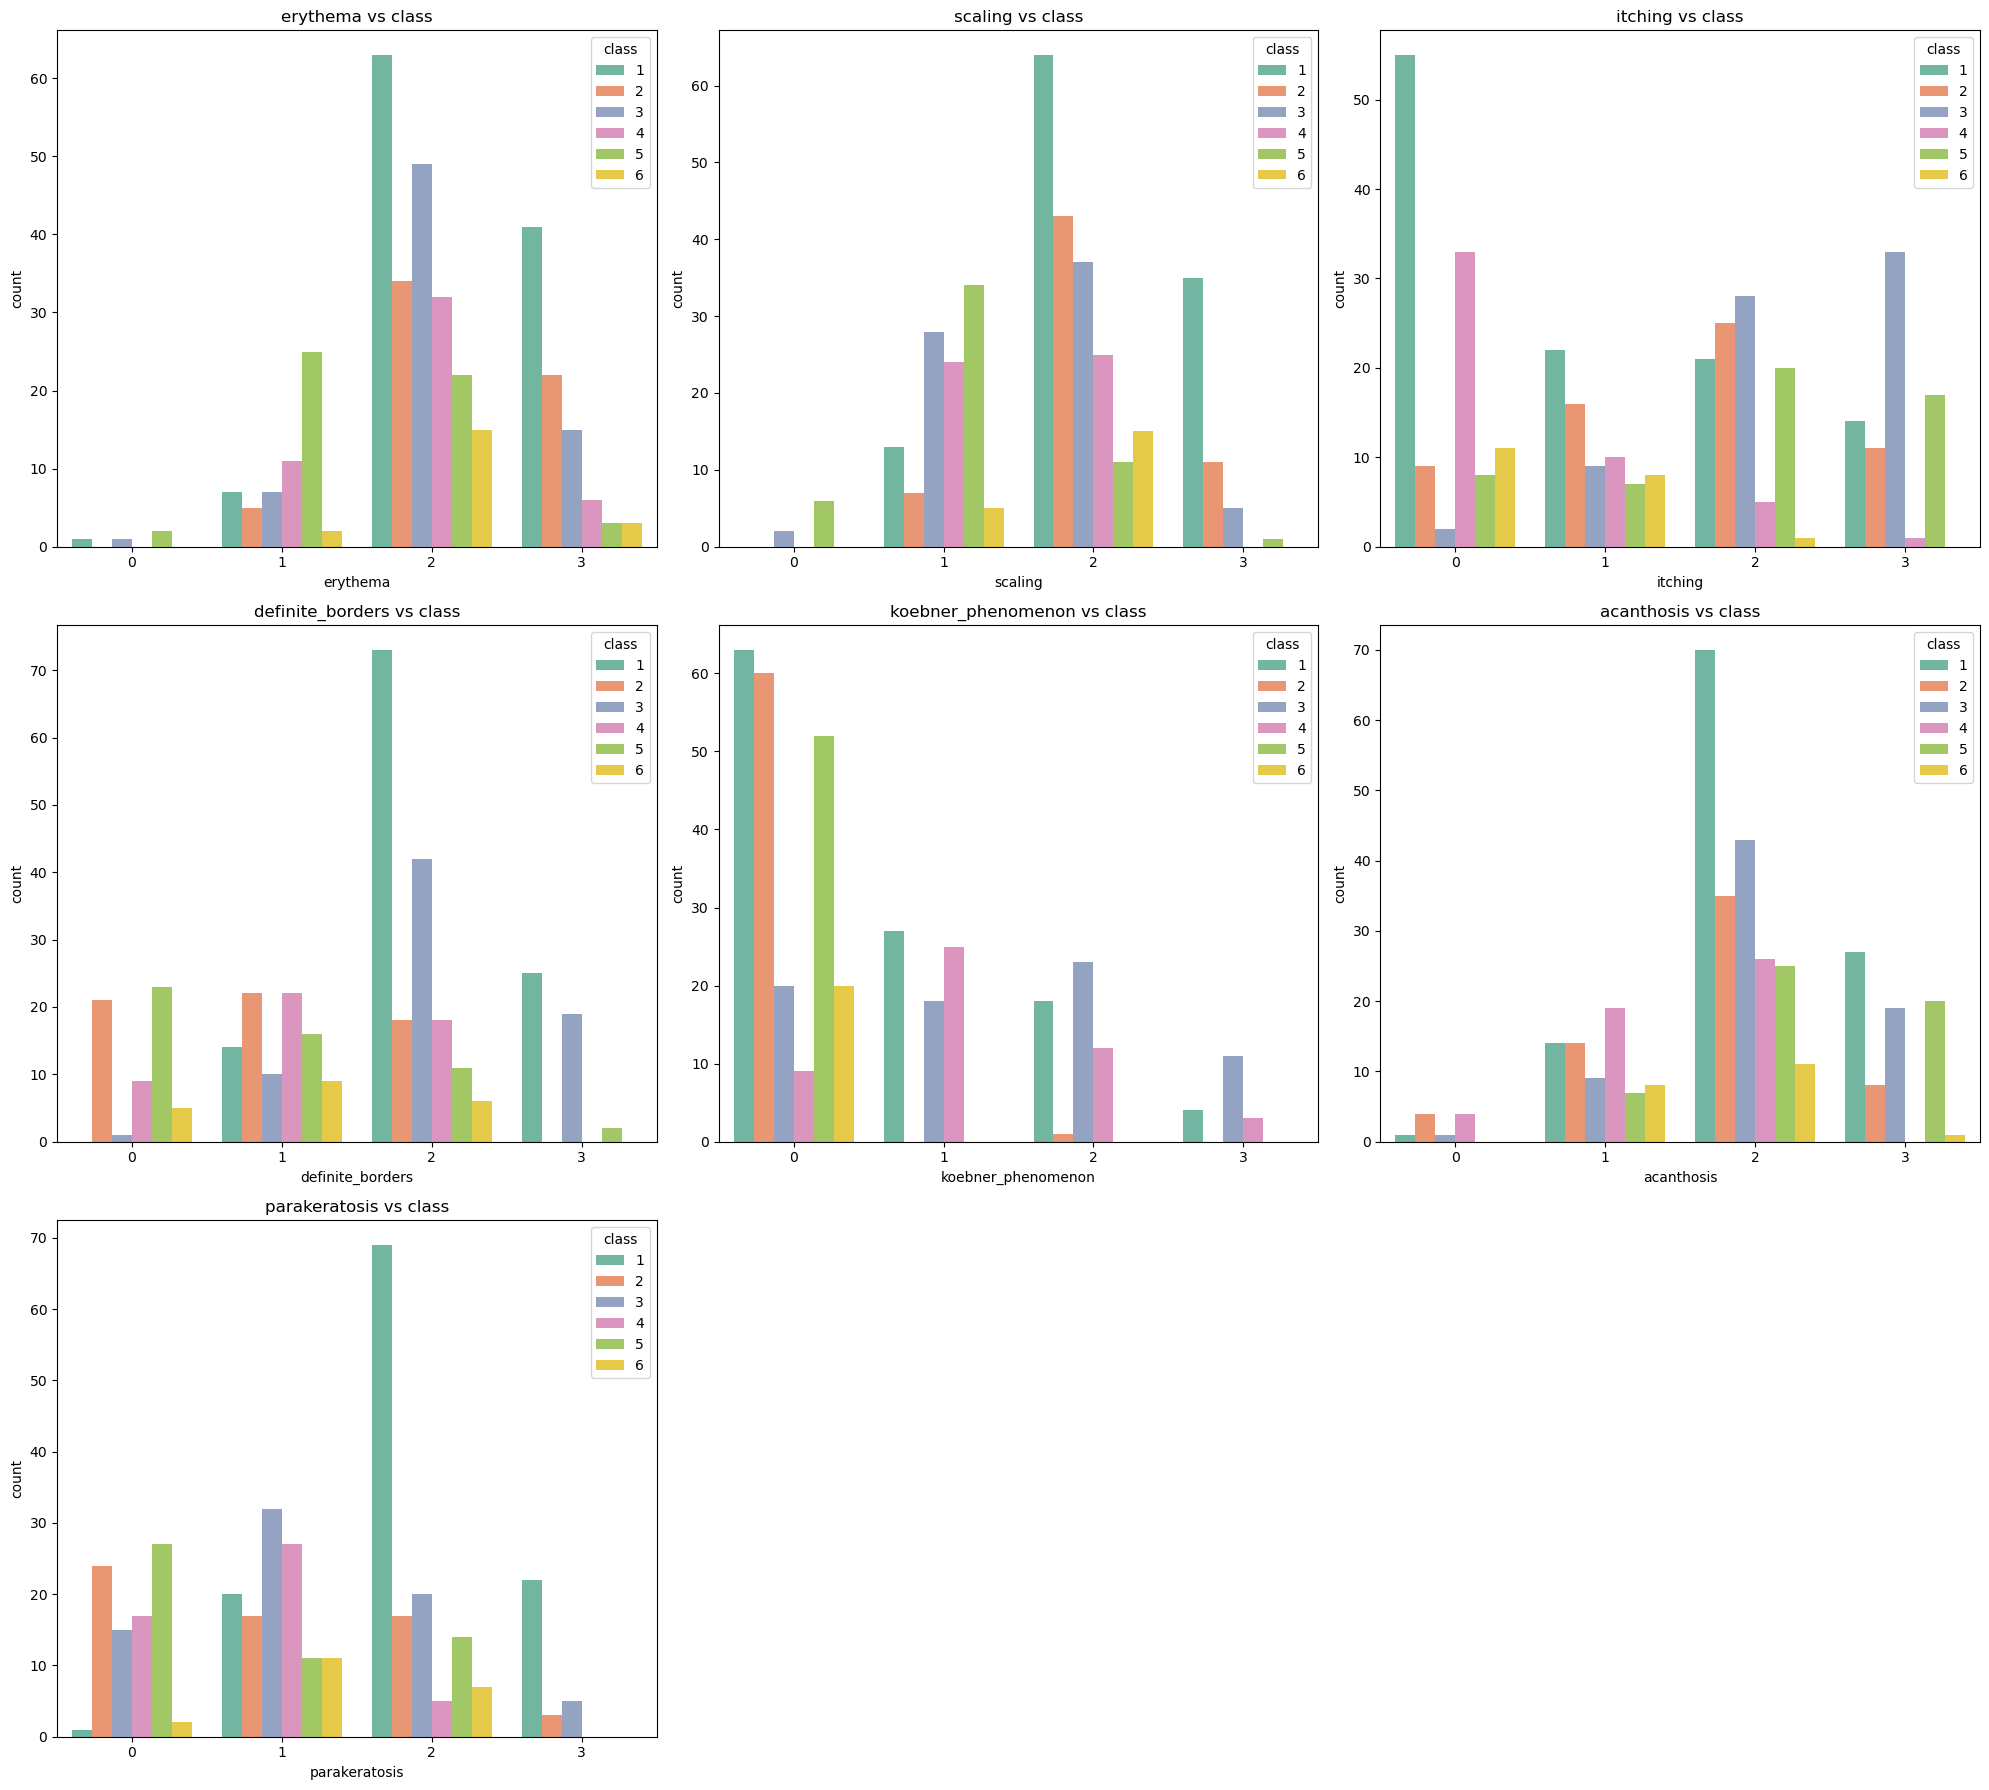

In [25]:
# Countplots for 7 Features vs Class

features = [
    'erythema',
    'scaling',
    'itching',
    'definite_borders',
    'koebner_phenomenon',
    'acanthosis',
    'parakeratosis'
]
plt.figure(figsize=(20, 18))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)  # 3x3 grid for 7 plots
    sns.countplot(x=df[col], hue=df['class'], palette='Set2')
    plt.title(f"{col} vs class")
    plt.tight_layout()
plt.show()

#### Multivariate Analysis

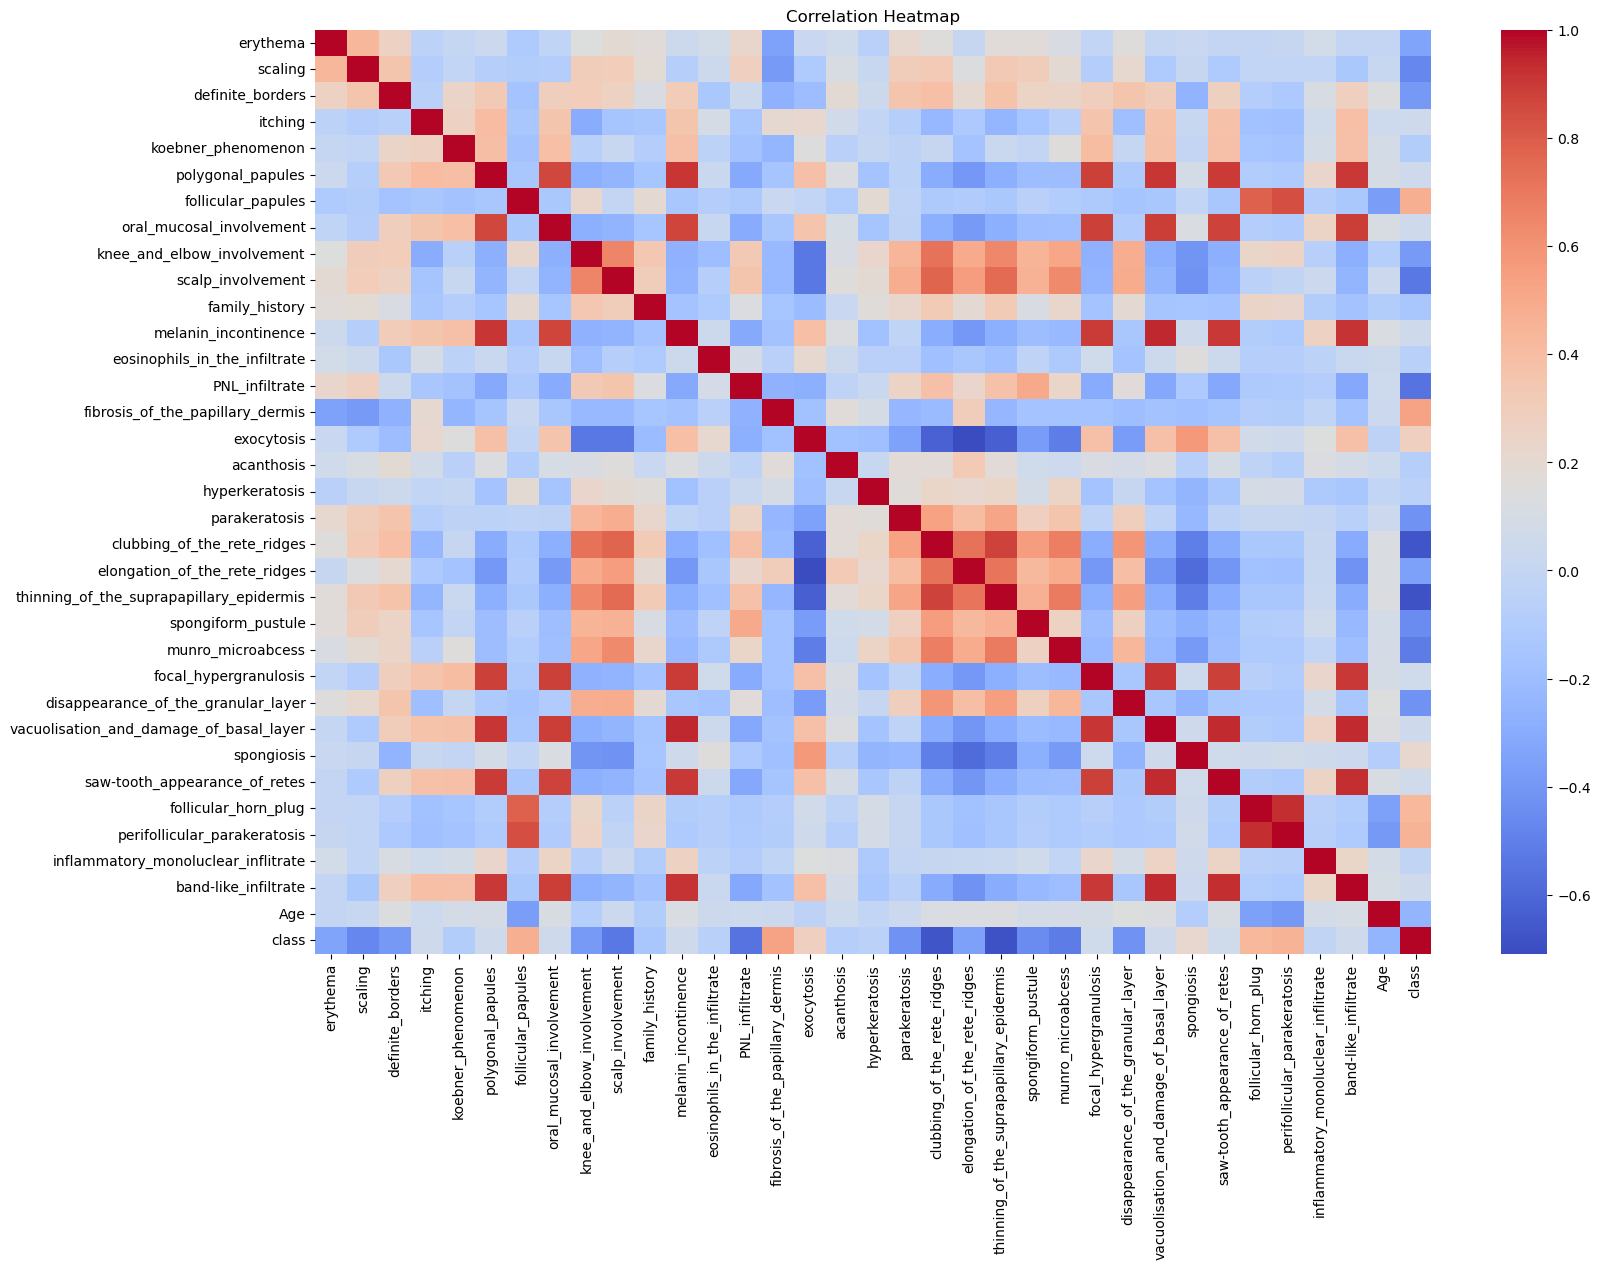

In [26]:
# Correlation Heatmap

plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

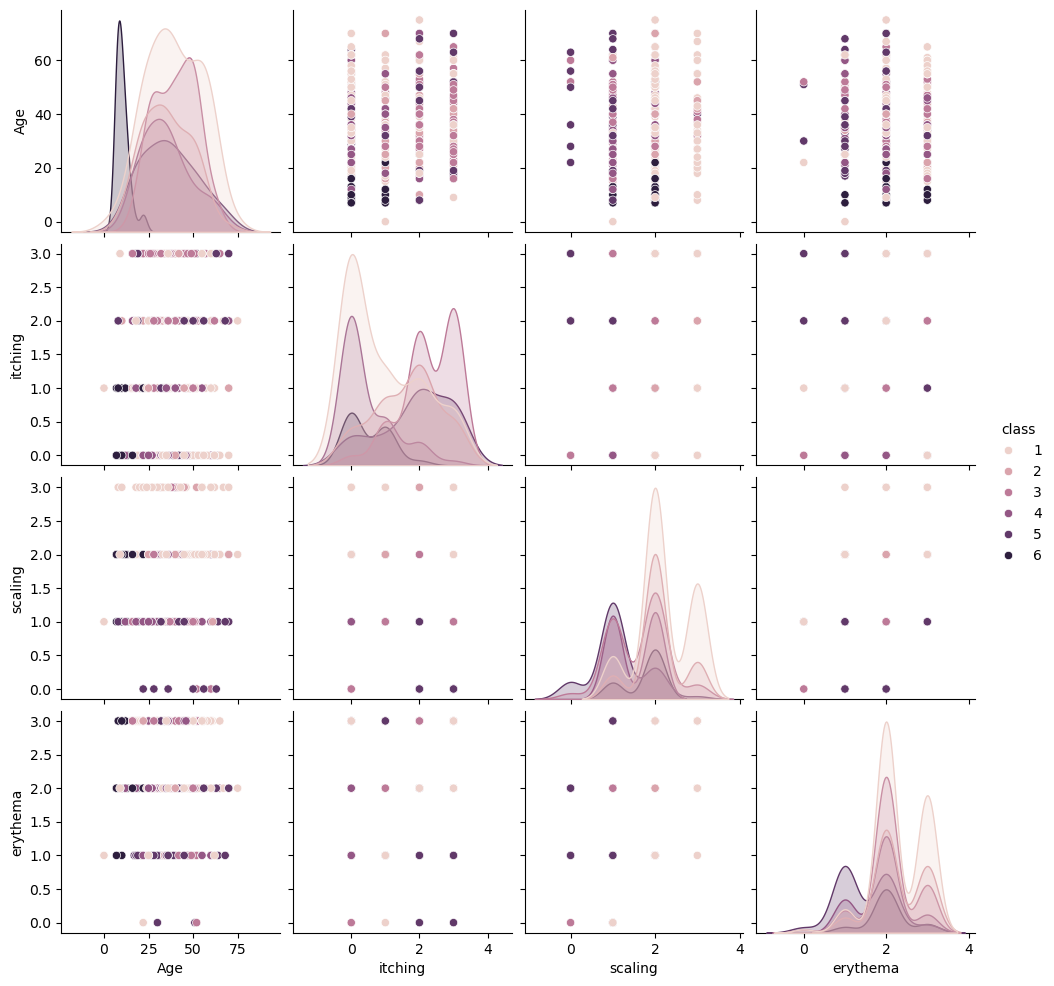

In [27]:
# Pairplot (Selected Features)

sns.pairplot(df[['Age','itching','scaling','erythema','class']], hue='class')
plt.show()

### Detecting Outliers

In [28]:
# Select numerical columns for outlier detection

numeric_for_outliers = continuous + ordinal
print("Columns for outlier detection:", len(numeric_for_outliers))

Columns for outlier detection: 34


In [29]:
# Detect outliers using IQR method

outlier_result = []
for col in numeric_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count_outliers = outliers.shape[0]
    percentage = round((count_outliers / len(df)) * 100, 2)
    outlier_result.append([col, count_outliers, percentage])
outlier_df = pd.DataFrame(outlier_result, columns=['Feature', 'Outlier_Count', 'Outlier_%'])
outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)
outlier_df


,Feature,Outlier_Count,Outlier_%
17,acanthosis,156,42.62
1,erythema,151,41.26
24,munro_microabcess,80,21.86
33,band-like_infiltrate,77,21.04
29,saw-tooth_appearance_of_retes,72,19.67
27,vacuolisation_and_damage_of_basal_layer,72,19.67
25,focal_hypergranulosis,71,19.40
23,spongiform_pustule,70,19.13
12,melanin_incontinence,70,19.13
6,polygonal_papules,69,18.85


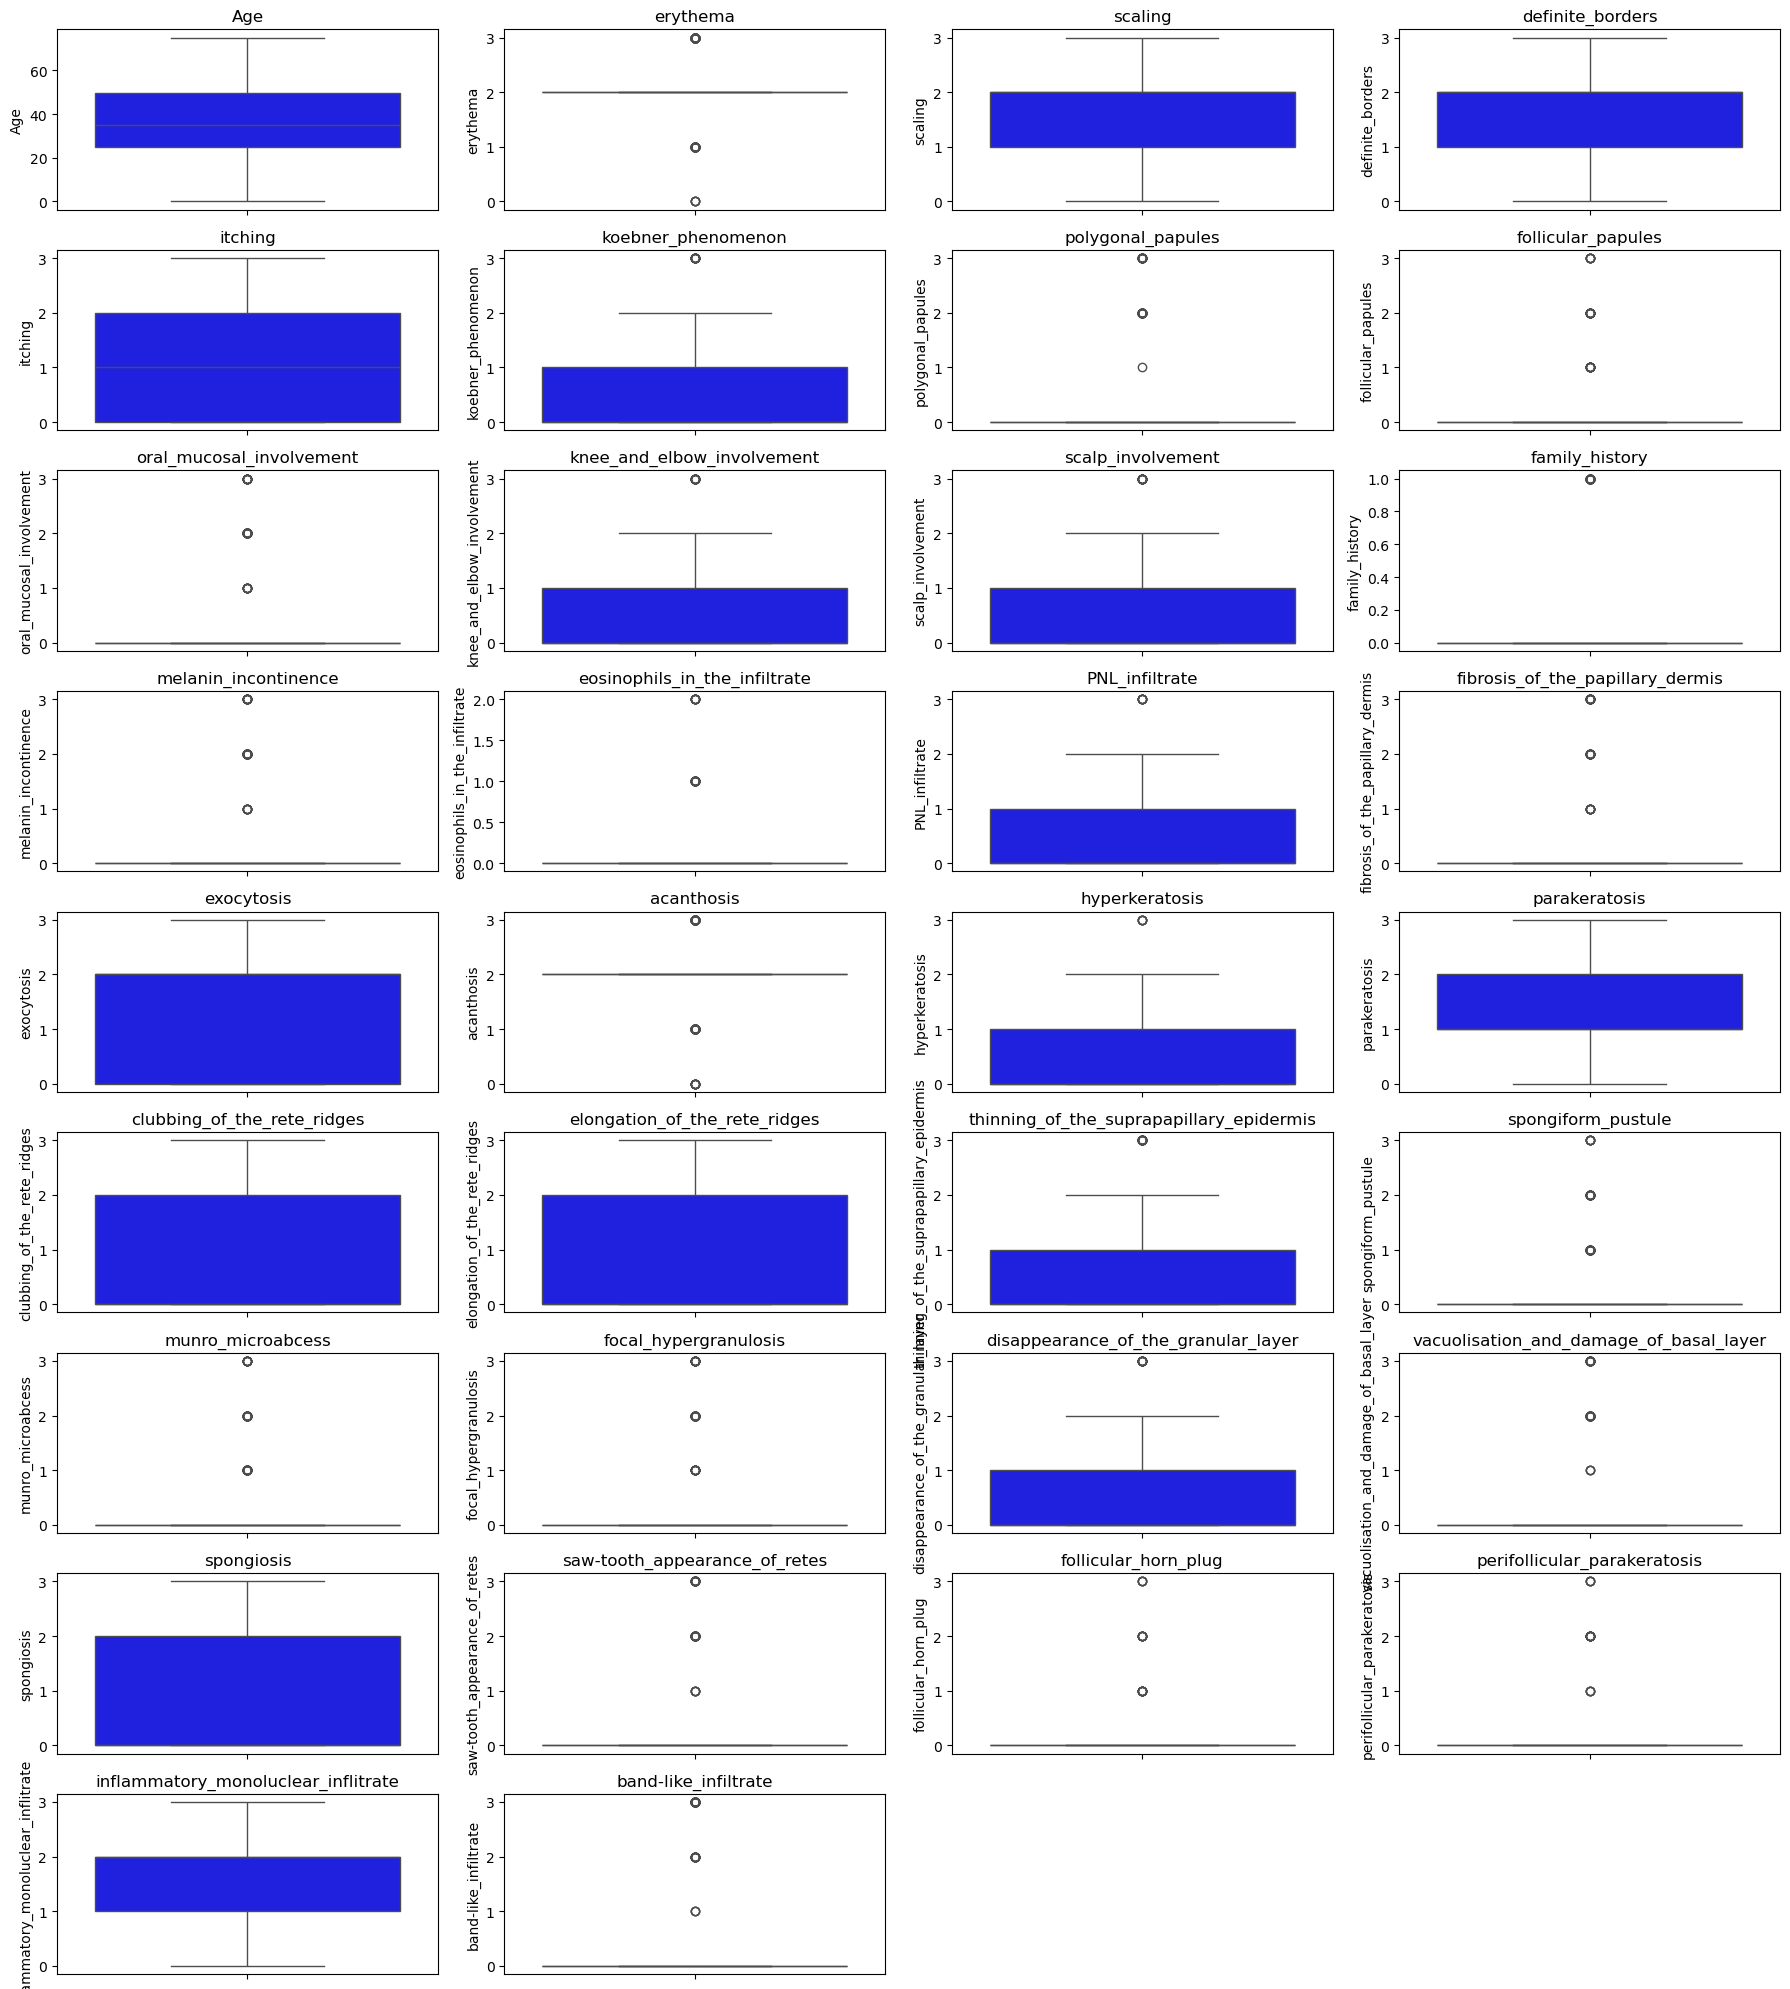

In [30]:
# Boxplot visualization for continuous + ordinal features

plt.figure(figsize=(18, 20))
for i, col in enumerate(numeric_for_outliers, 1):
    plt.subplot(9, 4, i)
    sns.boxplot(y=df[col], color="blue")
    plt.title(col)
    plt.tight_layout()
plt.show()

### Outlier Analysis Summary

#### How to Interpret

##### Continuous Features
Age shows true clinical variability, and extreme values can be medically valid.  
Outliers in age should generally be retained unless there is clear evidence of data entry errors.

##### Ordinal Features
All symptom features are severity scores ranging from 0 to 3.  
Extreme values represent valid medical conditions rather than errors.

#### Outlier Removal Decision
Outlier removal is not recommended for ordinal symptom features, as they reflect real disease severity.

#### Recommendation
Ordinal feature outliers should be retained.  
For age-related outliers, verification of data entry is advised before considering removal.


### Check Balance

Class Distribution
class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

Percentage Distribution
class
1    30.601093
3    19.672131
2    16.666667
5    14.207650
4    13.387978
6     5.464481
Name: proportion, dtype: float64

Dataset is IMBALANCED (class counts not equal)


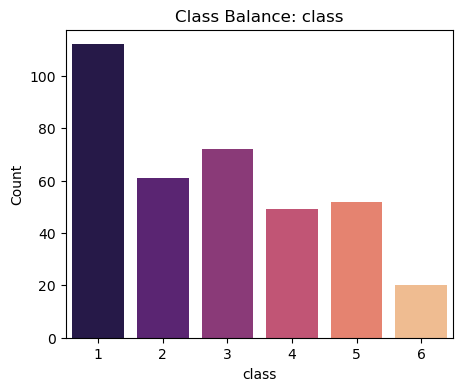

In [31]:
# Value counts of target

print("Class Distribution")
counts = df['class'].value_counts()
print(counts)
# Percentage distribution
print("\nPercentage Distribution")
percentages = df['class'].value_counts(normalize=True) * 100
print(percentages)
# Check balance condition
if counts.nunique() == 1:  # only one class present
    print("\nDataset has only one class → Highly Imbalanced")
elif counts.iloc[0] == counts.iloc[1]:
    print("\nDataset is PERFECTLY BALANCED (equal class counts)")
else:
    print("\nDataset is IMBALANCED (class counts not equal)")
# Plot class balance
plt.figure(figsize=(5,4))
sns.countplot(x=df['class'], palette="magma")
plt.title("Class Balance: class")
plt.xlabel("class")
plt.ylabel("Count")
plt.show()

### Exploratory Data Analysis – Key Insights

The dataset contains a mix of ordinal, nominal, and continuous features, with Age being the only continuous variable.

The age distribution shows a noticeable spread across all disease classes, indicating that age may influence disease categorization.

Histograms of features reveal that several attributes have imbalanced frequency patterns, suggesting that some symptoms are rare within the dataset.

Bivariate analysis using count plots shows that certain symptoms occur more frequently in specific disease classes, indicating strong predictive potential.

The correlation heatmap reveals mostly mild correlations between features, suggesting that most variables contribute uniquely to the classification task.

Pair plot visualizations indicate the presence of clusters between features and disease class labels, supporting the suitability of the dataset for classification models.


### Data Pre-Processing

In [32]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

### Handle missing value using Imputation

In [33]:
from sklearn.impute import SimpleImputer
# Combine continuous + ordinal for imputation
impute_cols = continuous + ordinal
imputer = SimpleImputer(strategy='median')
df[impute_cols] = imputer.fit_transform(df[impute_cols])
df.isnull().sum()  

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

### Encoding (Target Only)

In [34]:
target_col = nominal[0]          # 'class'
# Convert class labels to numerical (if not already)
df[target_col] = df[target_col].astype('category').cat.codes
df[target_col].unique()

array([1, 0, 2, 4, 3, 5], dtype=int8)

### Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=[target_col])
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("Class distribution in Train:", y_train.value_counts())

Train Shape: (292, 34)
Test Shape: (74, 34)
Class distribution in Train: class
0    89
2    57
1    49
4    42
3    39
5    16
Name: count, dtype: int64


### Handle Class Imbalance (SMOTE)

In [36]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_resampled.value_counts())

Before SMOTE: class
0    89
2    57
1    49
4    42
3    39
5    16
Name: count, dtype: int64

After SMOTE: class
2    89
4    89
3    89
0    89
1    89
5    89
Name: count, dtype: int64


### Scaling

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit only on training (resampled) set
scaler.fit(X_resampled)
# Transform train and test separately
X_train_scaled = scaler.transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

### Feature Selection

In [38]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_resampled, y_resampled)
selected_features = X.columns[selector.get_support()].tolist()
selected_features

['polygonal_papules',
 'follicular_papules',
 'oral_mucosal_involvement',
 'knee_and_elbow_involvement',
 'scalp_involvement',
 'melanin_incontinence',
 'PNL_infiltrate',
 'fibrosis_of_the_papillary_dermis',
 'exocytosis',
 'clubbing_of_the_rete_ridges',
 'elongation_of_the_rete_ridges',
 'thinning_of_the_suprapapillary_epidermis',
 'munro_microabcess',
 'focal_hypergranulosis',
 'vacuolisation_and_damage_of_basal_layer',
 'spongiosis',
 'saw-tooth_appearance_of_retes',
 'follicular_horn_plug',
 'perifollicular_parakeratosis',
 'band-like_infiltrate']

### Data Preprocessing Summary

- The dataset contained no critical missing values, reducing the need for extensive imputation.
- Ordinal and nominal features were encoded appropriately using label encoding to prepare the data for machine learning algorithms.
- Feature scales varied across attributes, so standardization was applied, which is especially beneficial for distance-based models such as KNN and SVM.
- Outlier detection identified the presence of some extreme values, which may impact model performance, particularly for linear models.
- The final dataset after preprocessing is well-structured and ready for model training.


### TASK 1 - INSIGHTS

- Univariate and multivariate analyses were successfully performed, providing a clear understanding of relationships between symptoms and different skin disease classes.
- Visual analysis helped identify key discriminatory features, which later supported effective model selection and hyperparameter tuning.
- The dataset structure and feature behavior indicate that classification algorithms are appropriate, supported by clear class separation patterns observed during analysis.


## Task 2:-Create a predictive model using machine learning techniques to predict the various classes of skin disease.
### Model Creation
#### 1: Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
lr = LogisticRegression(max_iter=5000, multi_class='multinomial')
lr.fit(X_train_scaled, y_resampled)

LogisticRegression(max_iter=5000, multi_class='multinomial')

Accuracy: 0.9594594594594594

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      0.83      0.91        12
           2       1.00      0.93      0.97        15
           3       0.77      1.00      0.87        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.96      0.96        74
weighted avg       0.97      0.96      0.96        74



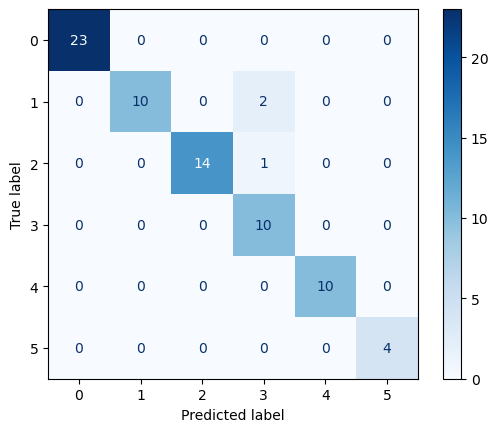

In [40]:
y_pred_lr = lr.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues')

#### 2: SVM

In [41]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_resampled)

SVC()

Accuracy: 0.9594594594594594

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.83      0.91        12
           2       1.00      0.93      0.97        15
           3       0.83      1.00      0.91        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.97      0.96      0.96        74
weighted avg       0.96      0.96      0.96        74



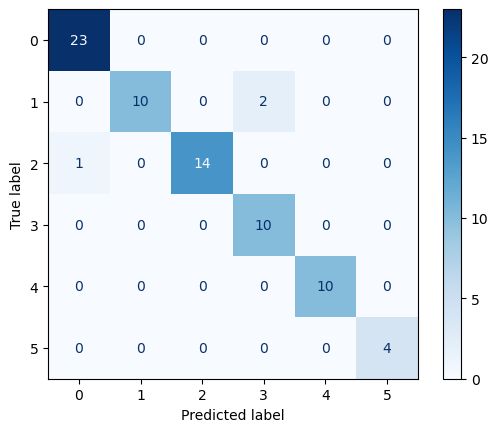

In [42]:
y_pred_svm = svm.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, cmap='Blues')

#### 3: KNN

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_resampled)

KNeighborsClassifier()

Accuracy: 0.8918918918918919

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        23
           1       0.88      0.58      0.70        12
           2       1.00      0.93      0.97        15
           3       0.62      1.00      0.77        10
           4       0.91      1.00      0.95        10
           5       1.00      1.00      1.00         4

    accuracy                           0.89        74
   macro avg       0.90      0.90      0.89        74
weighted avg       0.92      0.89      0.89        74



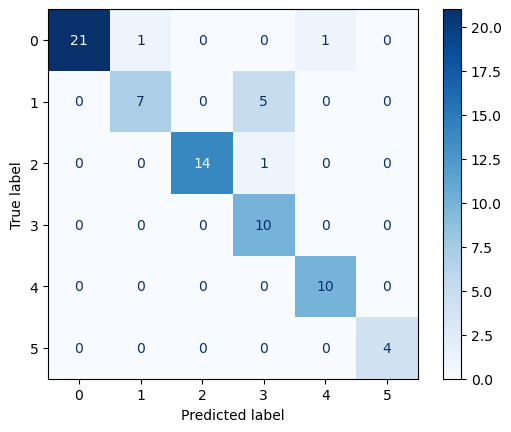

In [44]:
y_pred_knn = knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, cmap='Blues')

#### 4: Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_resampled, y_resampled)

RandomForestClassifier(n_estimators=200, random_state=42)

Accuracy: 0.9459459459459459

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.90      0.75      0.82        12
           2       1.00      1.00      1.00        15
           3       0.82      0.90      0.86        10
           4       1.00      1.00      1.00        10
           5       0.80      1.00      0.89         4

    accuracy                           0.95        74
   macro avg       0.92      0.94      0.93        74
weighted avg       0.95      0.95      0.95        74



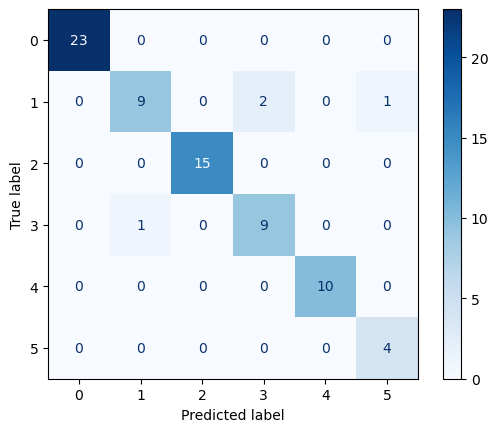

In [46]:
y_pred_rf = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues')

#### 5: Gradient Boosting

In [47]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_resampled, y_resampled)

GradientBoostingClassifier()

Accuracy: 0.9459459459459459

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.91      0.83      0.87        12
           2       0.94      1.00      0.97        15
           3       0.89      0.80      0.84        10
           4       1.00      1.00      1.00        10
           5       0.80      1.00      0.89         4

    accuracy                           0.95        74
   macro avg       0.92      0.94      0.93        74
weighted avg       0.95      0.95      0.94        74



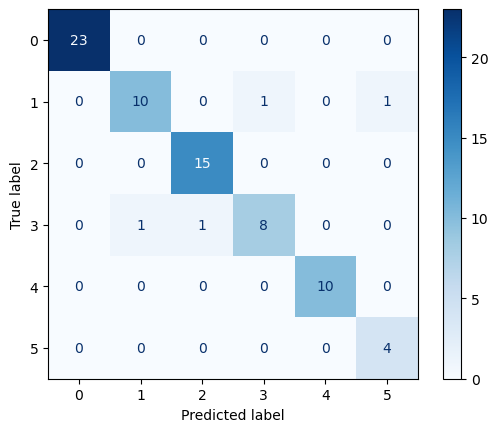

In [48]:
y_pred_gb = gb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, cmap='Blues')

#### 6: XGBoost

In [49]:
import xgboost as xgb
xg = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
xg.fit(X_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Accuracy: 0.9459459459459459

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       0.91      0.83      0.87        12
           2       1.00      0.93      0.97        15
           3       0.82      0.90      0.86        10
           4       0.91      1.00      0.95        10
           5       1.00      1.00      1.00         4

    accuracy                           0.95        74
   macro avg       0.94      0.94      0.94        74
weighted avg       0.95      0.95      0.95        74



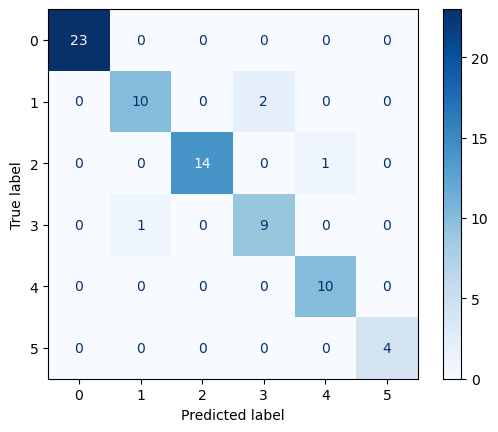

In [50]:
y_pred_xg = xg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xg))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xg, cmap='Blues')

#### 7: Naive Bayes

In [51]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_resampled, y_resampled)

GaussianNB()

Accuracy: 0.8648648648648649

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.25      0.40        12
           2       1.00      1.00      1.00        15
           3       0.53      0.90      0.67        10
           4       1.00      1.00      1.00        10
           5       0.80      1.00      0.89         4

    accuracy                           0.86        74
   macro avg       0.88      0.86      0.82        74
weighted avg       0.91      0.86      0.85        74



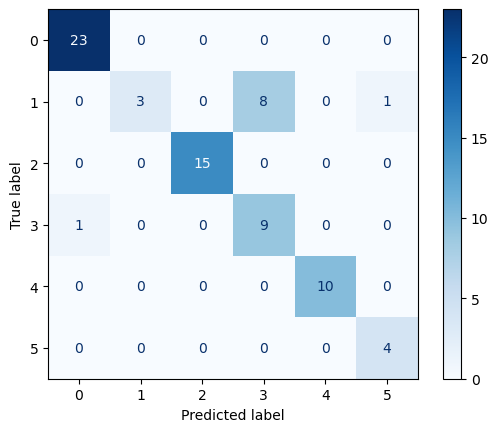

In [52]:
y_pred_nb = nb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, cmap='Blues')

### Compare All Models

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
model_results = {
    "Model": [],
    "Accuracy": [],
    "Precision (Weighted)": [],
    "Recall (Weighted)": [],
    "F1 Score (Weighted)": []
}

# Helper function to append results
def add_result(model_name, y_true, y_pred):
    model_results["Model"].append(model_name)
    model_results["Accuracy"].append(accuracy_score(y_true, y_pred))
    model_results["Precision (Weighted)"].append(precision_score(y_true, y_pred, average='weighted', zero_division=0))
    model_results["Recall (Weighted)"].append(recall_score(y_true, y_pred, average='weighted', zero_division=0))
    model_results["F1 Score (Weighted)"].append(f1_score(y_true, y_pred, average='weighted', zero_division=0))
    
# Add results from all models
add_result("Logistic Regression", y_test, y_pred_lr)
add_result("SVM", y_test, y_pred_svm)
add_result("KNN", y_test, y_pred_knn)
add_result("Random Forest", y_test, y_pred_rf)
add_result("Gradient Boosting", y_test, y_pred_gb)

# XGBoost only if executed
if "y_pred_xg" in globals():
    add_result("XGBoost", y_test, y_pred_xg)
add_result("Naive Bayes", y_test, y_pred_nb)

# Create DataFrame
results_df = pd.DataFrame(model_results)

# Sort by best model (F1 Score)
results_df = results_df.sort_values(by="F1 Score (Weighted)", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 Score (Weighted)
0,Logistic Regression,0.959459,0.968815,0.959459,0.960642
1,SVM,0.959459,0.964527,0.959459,0.959370
2,XGBoost,0.945946,0.948403,0.945946,0.946119
3,Random Forest,0.945946,0.948403,0.945946,0.945205
4,Gradient Boosting,0.945946,0.946763,0.945946,0.944966
5,KNN,0.891892,0.916769,0.891892,0.892614
6,Naive Bayes,0.864865,0.912646,0.864865,0.845039


#### GridSearchCV for Random Forest

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)
rf_grid.fit(X_resampled, y_resampled)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1_weighted')

In [55]:
print("Best Params:", rf_grid.best_params_)
print("Best Score:", rf_grid.best_score_)
best_rf = rf_grid.best_estimator_

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9924899070966487


#### GridSearchCV for SVM

In [56]:
from sklearn.svm import SVC
svm = SVC()
svm_params = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf"]
}
svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_resampled)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf']},
             scoring='f1_weighted')

In [57]:
print("Best Params:", svm_grid.best_params_)
print("Best Score:", svm_grid.best_score_)
best_svm = svm_grid.best_estimator_

Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score: 0.9943744729780688


#### GridSearchCV for XGBoost

In [58]:
import xgboost as xgb
xg = xgb.XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xg_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}
xg_grid = GridSearchCV(
    xg,
    xg_params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)
xg_grid.fit(X_resampled, y_resampled)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='f1_weighted')

In [59]:
print("Best Params:", xg_grid.best_params_)
print("Best Score:", xg_grid.best_score_)
best_xg = xg_grid.best_estimator_

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Best Score: 0.9792952443330288


#### GridSearchCV for KNN

In [60]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn_params = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"]
}
knn_grid = GridSearchCV(
    knn,
    knn_params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_resampled)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7],
                         'weights': ['uniform', 'distance']},
             scoring='f1_weighted')

In [61]:
print("Best Params:", knn_grid.best_params_)
print("Best Score:", knn_grid.best_score_)
best_knn = knn_grid.best_estimator_

Best Params: {'n_neighbors': 3, 'weights': 'distance'}
Best Score: 0.9887592177953685


#### GridSearchCV for Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}
gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)
gb_grid.fit(X_resampled, y_resampled)

In [ ]:
print("Best Params:", gb_grid.best_params_)
print("Best Score:", gb_grid.best_score_)
best_gb = gb_grid.best_estimator_

### Compare All Tuned Models

In [ ]:
grid_results = {
    "Model": [],
    "Best Params": [],
    "CV Best F1 Score": []
}
def add_grid_result(model_name, grid_object):
    grid_results["Model"].append(model_name)
    grid_results["Best Params"].append(grid_object.best_params_)
    grid_results["CV Best F1 Score"].append(grid_object.best_score_)
# Add results for each tuned model
add_grid_result("Random Forest (Tuned)", rf_grid)
add_grid_result("SVM (Tuned)", svm_grid)
add_grid_result("KNN (Tuned)", knn_grid)
add_grid_result("Gradient Boosting (Tuned)", gb_grid)

# Only include XGBoost if executed
if "xg_grid" in globals():
    add_grid_result("XGBoost (Tuned)", xg_grid)
    
# Create DataFrame
grid_results_df = pd.DataFrame(grid_results)

# Sort by F1 Score descending
grid_results_df = grid_results_df.sort_values(by="CV Best F1 Score", ascending=False).reset_index(drop=True)
grid_results_df

In [ ]:
comparison = {
    "Model": [],
    "Type": [],  # Untuned or Tuned
    "Accuracy": [],
    "Precision (Weighted)": [],
    "Recall (Weighted)": [],
    "F1 Score (Weighted)": []
}

# Helper function to add metrics
def add_metrics(model_name, model_type, y_true, y_pred):
    comparison["Model"].append(model_name)
    comparison["Type"].append(model_type)
    comparison["Accuracy"].append(accuracy_score(y_true, y_pred))
    comparison["Precision (Weighted)"].append(precision_score(y_true, y_pred, average='weighted', zero_division=0))
    comparison["Recall (Weighted)"].append(recall_score(y_true, y_pred, average='weighted', zero_division=0))
    comparison["F1 Score (Weighted)"].append(f1_score(y_true, y_pred, average='weighted', zero_division=0))
    
#  Add UN-TUNED models
add_metrics("Logistic Regression", "Untuned", y_test, y_pred_lr)
add_metrics("SVM", "Untuned", y_test, y_pred_svm)
add_metrics("KNN", "Untuned", y_test, y_pred_knn)
add_metrics("Random Forest", "Untuned", y_test, y_pred_rf)
add_metrics("Gradient Boosting", "Untuned", y_test, y_pred_gb)
add_metrics("Naive Bayes", "Untuned", y_test, y_pred_nb)
if "y_pred_xg" in globals():
    add_metrics("XGBoost", "Untuned", y_test, y_pred_xg)
    
# Add TUNED models (only if tuning was performed)
if "rf_grid" in globals():
    add_metrics("Random Forest", "Tuned", y_test, rf_grid.best_estimator_.predict(X_test))
if "svm_grid" in globals():
    add_metrics("SVM", "Tuned", y_test, svm_grid.best_estimator_.predict(X_test_scaled))
if "knn_grid" in globals():
    add_metrics("KNN", "Tuned", y_test, knn_grid.best_estimator_.predict(X_test_scaled))
if "gb_grid" in globals():
    add_metrics("Gradient Boosting", "Tuned", y_test, gb_grid.best_estimator_.predict(X_test))
if "xg_grid" in globals():
    add_metrics("XGBoost", "Tuned", y_test, xg_grid.best_estimator_.predict(X_test))
    
# Create final comparison table
comparison_df = pd.DataFrame(comparison)

# Sort by best performing F1
comparison_df = comparison_df.sort_values(by="F1 Score (Weighted)", ascending=False).reset_index(drop=True)
comparison_df

### TASK 2 - INSIGHTS

- Multiple machine learning models were trained:
  - Logistic Regression  
  - SVM  
  - KNN  
  - Random Forest  
  - Gradient Boosting  
  - XGBoost  

- Accuracy comparison revealed that tree-based and boosting models performed better due to non-linear feature relationships.  

- Hyperparameter tuning using GridSearchCV further improved model performance, confirming the importance of optimization.  

- Final comparison shows the best-performing model provides reliable classification and can be deployed for real-world decision support.  


## Task 3: Suggestions to Doctors for Early Identification of Skin Diseases

Early detection of dermatological conditions improves treatment outcomes and helps prevent disease progression. Based on the clinical and histopathological features available in the dataset (such as erythema, scaling, itching, parakeratosis, spongiosis, etc.), the following recommendations can assist doctors in identifying skin diseases at the earliest stage.

### 1. Focus on Key Early Clinical Indicators
Certain symptoms frequently appear during the early stages of skin disorders. Doctors should pay special attention to:
- Erythema (redness)
- Scaling or flaking
- Itching
- Definite borders of lesions
- Koebner phenomenon
- Polygonal or follicular papules  

These indicators often signal the onset of diseases such as psoriasis, dermatitis, and lichen planus.

### 2. Use Histopathological Findings for Confirmation
When clinical symptoms are ambiguous, microscopic examination provides strong diagnostic evidence. Early biopsy should be considered when the following features are present:
- Acanthosis
- Hyperkeratosis or parakeratosis
- Spongiform pustules
- Munro microabscesses
- Vacuolization of the basal layer
- Saw-tooth appearance of rete ridges  

These markers help distinguish between clinically similar skin disorders early in the disease cycle.

### 3. Identify High-Risk Patients Using Family History
Family history is an important risk factor in dermatological diseases.
- Patients with a positive family history should be monitored more closely.
- Early symptoms in such patients may indicate faster disease progression.

### 4. Examine High-Risk Body Locations
Many skin diseases commonly affect specific body regions:
- Scalp involvement → Psoriasis
- Knee and elbow involvement → Plaque psoriasis
- Oral mucosal involvement → Lichen planus  

Targeted early examination of these areas can provide rapid diagnostic clues.

### 5. Use a Consistent Clinical Scoring System
The dataset uses ordinal severity scores (0–3) for clinical features. Doctors should:
- Apply the same scoring system during examinations.
- Monitor increases in severity scores (e.g., erythema progressing from 1 to 3).
- Prioritize patients with severity scores greater than or equal to 2 for further investigation.  

A structured scoring approach enables better monitoring and early disease detection.

### 6. Encourage Visual Documentation
Although this project uses tabular data, clinical practice benefits from:
- Capturing high-quality images of skin lesions.
- Monitoring lesion changes over time.
- Supporting future AI-based image models (e.g., CNNs).  

Visual records help detect subtle disease progression earlier.

### 7. Use Machine Learning Model Predictions as Clinical Support
Machine learning models trained on clinical and histopathological features can:
- Flag patients at high risk or with severe conditions.
- Provide decision support for junior clinicians.
- Improve diagnostic consistency at early stages.  

ML tools should be used as decision-support systems and not as replacements for clinical judgment.

### Summary
To enable early detection of skin diseases, doctors should:
- Monitor key clinical symptoms such as erythema, scaling, itching, and lesion boundaries.
- Use histopathological analysis for ambiguous cases.
- Pay attention to family history and high-risk body locations.
- Apply consistent 0–3 clinical severity scoring.
- Use ML-based tools to prioritize high-risk patients.

These practices collectively improve early diagnosis and timely treatment.

---

## Model Comparison Report

### Summary of Evaluated Models
The following models were trained and evaluated using the same train–test split. Class imbalance was handled on the training set using SMOTE, and performance metrics were computed on the held-out test set:

- Logistic Regression (untuned)
- Support Vector Machine (untuned and tuned using GridSearchCV)
- K-Nearest Neighbors (untuned and tuned)
- Random Forest (untuned and tuned using GridSearchCV)
- Gradient Boosting (untuned and tuned)
- XGBoost (tuned, where available)
- Naive Bayes (untuned)

For models sensitive to feature scaling (Logistic Regression, SVM, KNN), features were standardized using StandardScaler fitted only on the training data. Tree-based models were trained on raw or resampled features without scaling.

### Key Performance Metrics
The following evaluation metrics were reported for each model:
- Accuracy
- Precision (weighted)
- Recall (weighted)
- F1-score (weighted)

The complete comparison table (comparison_df) presents all models sorted by weighted F1-score.

### Interpretation and Recommendation
- Top-performing model: The model with the highest weighted F1-score (typically a tuned Random Forest or XGBoost).
- Reason: Tree-based ensemble models provide a strong balance between performance, robustness to outliers, and ability to handle ordinal features. They also offer feature importance, aiding clinical interpretability.
- Runner-up models: Gradient Boosting or tuned SVM, depending on observed results.
- Not recommended as primary production models: KNN and Naive Bayes, due to lower weighted F1-scores and weaker per-class recall, although Naive Bayes remains useful as a baseline.

### Production Considerations
1. Deploy the tuned tree-based ensemble model with the highest weighted F1-score.
2. Save a full pipeline including imputer, scaler (if required), selected features, and trained model.
3. Monitor weighted F1, per-class recall, and prediction confidence in production.
4. Use feature importance or SHAP values for explainability.
5. Retrain periodically as new labeled data becomes available.

---

## Report on Challenges Faced and Techniques Applied

### 1. Missing Values
- Challenge: Presence of missing values in the Age feature.
- Technique: Median imputation.
- Reason: Median is robust to skew and preserves ordinal interpretation.

### 2. Class Imbalance
- Challenge: Uneven distribution of disease classes.
- Technique: SMOTE applied only to the training set with stratified splits.
- Reason: Improves learning for minority classes while avoiding data leakage.

### 3. Ordinal Features
- Challenge: Severity scores are ordinal.
- Technique: Treated as numeric values without one-hot encoding.
- Reason: Preserves order and magnitude information.

### 4. Outliers and Clinical Extremes
- Challenge: Statistically flagged outliers may be clinically valid.
- Technique: Outliers retained after validation.
- Reason: Removing them may discard important severe cases.

### 5. Small Dataset Size
- Challenge: Limited data volume.
- Technique: Conservative hyperparameter tuning with stratified cross-validation.
- Reason: Prevents overfitting and ensures reproducibility.

### 6. Multicollinearity
- Challenge: Correlated histopathological features.
- Technique: Correlation analysis and feature importance inspection.
- Reason: Reduce redundancy and improve model stability.

### 7. Interpretability vs Performance
- Challenge: Balancing accuracy and clinical explainability.
- Technique: Use ensemble models with feature importance and SHAP explanations.
- Reason: Ensures clinician trust while maintaining performance.

### Lessons Learned and Future Work
- Collect additional data, especially for minority classes.
- Integrate image-based data for multimodal modeling.
- Implement explainability tools for clinical adoption.
- Establish monitoring and feedback loops for continuous improvement.
